* ```Dúvidas```
    * O que distingue Interval e Ratio?? (basicamente se faz sentido ter 0 ou não nesse atributo(feature))
    * Não sei como devo obter os valores de referência das seguintes  features **IMC**, **SBP** e **DBP** (não sei como obter os valores de referencia para SBP E DBP)
        * Tentar descobrir usando ```Tables of blood pressure for children (in English) Ficheiro```.
        * A professora sugeriu remover objetos que tenham valores impossiveis em SBP,DBP,...
        * ```Ver Notes.ipynb que tem la sugestões sobre isso```
    * Mostrar o que tenho ate agora

# Análise da raw data 

In [2]:
# Enable autocomplete
%config IPCompleter.greedy=True

## Carregar os dados (com alguma limpeza para poder trabalhar com eles)

In [3]:
import pandas as pd 
import numpy as np 

In [4]:
raw_data = pd.read_excel('DataSets/UCMF.xls')

# Trocei valores invalidos (erros do excel) por np.nan
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
raw_data.replace('#VALUE!', np.nan, inplace=True)

# Corrigir dados que tem tipo incorreto (as vezes ao importar datasets isto pode acontecer)
raw_data['IDADE'] = raw_data['IDADE'].astype(float)


In [66]:
raw_data.head()

,ID,Peso,Altura,IMC,Atendimento,DN,IDADE,Convenio,PULSOS,PA SISTOLICA,...,PPA,NORMAL X ANORMAL,B2,SOPRO,FC,HDA 1,HDA2,SEXO,MOTIVO1,MOTIVO2
0,1,5.0,51,19.0,11/05/06,30/03/06,0.12,GS,Normais,NaN,...,Não Calculado,Anormal,Normal,Sistólico,112,Palpitacao,NaN,M,6 - Suspeita de cardiopatia,6 - Palpitação/taquicardia/arritmia
1,2,3.5,50,14.0,25/05/05,19/05/05,0.02,GS,Normais,NaN,...,Não Calculado,Anormal,Normal,ausente,128,Dispneia,NaN,M,6 - Suspeita de cardiopatia,6 - Dispnéia
2,3,0.0,0,NaN,12/06/01,08/05/05,-4.05,SULA,Normais,NaN,...,Não Calculado,Anormal,Normal,Sistólico,88,Assintomático,NaN,M,2 - Check-up,NaN
3,4,8.1,65,19.0,15/10/09,21/04/09,0.5,NaN,Normais,NaN,...,Não Calculado,Anormal,Normal,ausente,92,Assintomático,NaN,M,5 - Parecer cardiológico,NaN
4,5,39.5,142,20.0,23/01/09,24/10/99,9.6,Sulam,Normais,85.0,...,Normal,Anormal,Normal,ausente,90,NaN,NaN,M,5 - Parecer cardiológico,5 - Atividade física


## Descrição de variaveis 

### Tabela Resumo dos Tipos de Atributos

| Categoria | Tipo de Atributo | Significado | Operações Possíveis | Exemplos Simples |
| :---: | :---: | :--- | :--- | :--- |
| **Categórico** | **Nominal** | Rótulos/Nomes sem ordem. | Igualdade (=) e Diferença (!=). | Cor dos olhos, ID de Funcionário, Sexo/Género, Código Postal. |
| **Categórico** | **Ordinal** | Rótulos/Nomes com ordem. | Igualdade (=), Diferença (!=), Ordem (<, >). | Nível de satisfação, Graus académicos (A, B, C), Classificação (1.º, 2.º). |
| **Numérico** | **Interval** | Ordem e diferença significativa. Zero é arbitrário. | Ordem, Soma (+) e Subtração (-). Média é possível. | Temperatura (°C ou °F), Datas de Calendário. |
| **Numérico** | **Ratio** | Ordem, diferença significativa e zero absoluto. | Todas as operações: Ordem, Soma, Subtração, Multiplicação (*) e Divisão (/). | Idade, Peso, Altura, Tempo, Número de clientes, Temperatura em Kelvin. |


1. ```Categóricos Qualitativos```
    * Estes **atributos** representam **categorias** ou **grupos**.
        * ```Nominal```
            * Significado: Os valores são apenas **nomes** ou **labels**. A única coisa que podemos fazer é verificar se são **iguais ($\text{=}$)** ou **diferentes (!=)**.
            * Não há ordem, nem é possível fazer operações matemáticas como soma ou subtração.
        * ```Ordinal```
            * Significado: Além de serem diferentes, os valores têm uma **ordem** ou classificação.
            * Podemos dizer que um é **maior ($\text{>}$)** ou **menor ($\text{<}$)** que o outro.
            * No entanto, a distância entre os valores não é significativa ou não pode ser medida de forma consistente.
2. ```Numéricos Quantitativos```
    * Estes **atributos** representam **quantidades mensuráveis**.
        * ```Intervalo```
            * Significado: Os valores têm ordem, e a **diferença** entre dois valores é **significativa** (podemos subtrair e somar).
            * No entanto, o **zero é arbitrário** (**não significa a ausência total da propriedade**), o que **impede a realização de ratios** (divisão).
        * ```Ratio```
            * Significado: É o nível mais completo. Tem ordem, diferenças significativas, e um **zero absoluto** (**o zero significa a ausência total da propriedade**).
            * Isto permite que **todos os tipos de operações sejam aplicáveis**, incluindo **ratios (multiplicação e divisão)**.

### Tabela de classificação de tipos de atributos

> ```TODO: MOSTART CLASSIFICAÇÃO A PROFESSORA E VER SE BATE CERTO, ESPCIALMENTE NOS ATRIBUTOS:```
><br> --> **PA SISTOLICA**
><br> --> **PA DIASTOLICA**
><br> --< **FC**

| Atributo |  Descrição | Nominal |  Ordinal | Interval |  Ratio | Nota|
| :-------- | :-------- | :-------: | :-------: | :-------: | :-------: |  :-------: | 
| **ID**|  anonymized patient ID | X | | | |
| **Peso**| patient weight | | | | X |
| **Altura**| patient height  | | | | X | 
| **IMC**| body mass index | | | | X |
| **Atendimento**| date of visit | | X | ||
| **DN**| birth date | | X | | |
| **IDADE**| age | | | | X |
| **Convenio**|  health care insurance  | X | | | |
| **PULSOS**| pulses  | X| | | |
| **PA SISTOLICA**|  systolic blood pressure (SBP) | | | X| | Não é Ratio, porque o zero não significa a ausencia total da propriedade, i.e. zero é arbitrario (visto que o SBP = 0 ==> que a pessoa esta morta) 
| **PA DIASTOLICA**| diastolic blood pressure (DBP) | | | X | | 	Não é Ratio, porque o zero não significa a ausencia total da propriedade, i.e. zero é arbitrario (visto que o DBP = 0 ==> erro de medição)
| **PPA**| result SBP/DBP | X | |  |  |
| **NORMAL x ANORMAL**| absence or presence of pathology |  X | | | |
| **B2**| type of the second heart sound | X | | | |
| **SOPRO**|  murmur type | X | | | |
| **FC**| cardiac frequency | | | X | | Não é Ratio, porque o zero não significa a ausencia total da propriedade, i.e. zero é arbitrario (visto que o FC = 0 ==> que a pessoa esta morta)
| **HDA1**| histoy of disease 1 | X | | | |
| **HDA2**|  histoy of disease 2 (other history) | X | | | |
| **SEXO**|  patient gender | X | | | |
| **MOTIVO1**| first reason for being forwarded to the cardiology clinic | X | | | |
| **MOTIVO2**| second reason for being forwarded to the cardiology clinic  | X | | | |

### Reference values (detetar valores impossíveis, é precisso saber o que é um outlier e o que é um valor impossivel)

* ```Valores de referência de IMC``` (de acordo com Organização Mundial da Saude)
????

> **Nota** :Tinha varios estagios de obesidade, mas juntei todos num só

* ```Valore de referência SBP e DBP``` (para adultos, não encontrei especifiacamente para pessoas entre 2 e 19)

????

## Análise preliminar

### Sumários sobre os dados

In [117]:
raw_data.shape

(17873, 21)

In [110]:
raw_data.dtypes

ID                    int64
Peso                float64
Altura                int64
IMC                 float64
Atendimento          object
DN                   object
IDADE               float64
Convenio             object
PULSOS               object
PA SISTOLICA        float64
PA DIASTOLICA       float64
PPA                  object
NORMAL X ANORMAL     object
B2                   object
SOPRO                object
FC                   object
HDA 1                object
HDA2                 object
SEXO                 object
MOTIVO1              object
MOTIVO2              object
dtype: object

In [73]:
raw_data.describe(include='all')

,ID,Peso,Altura,IMC,Atendimento,DN,IDADE,Convenio,PULSOS,PA SISTOLICA,...,PPA,NORMAL X ANORMAL,B2,SOPRO,FC,HDA 1,HDA2,SEXO,MOTIVO1,MOTIVO2
count,17873.000000,17555.000000,17873.000000,13146.000000,16890,16497,16377.000000,12569,16675,10143.000000,...,17656,16705,16694,16706,15832.0,12459,652,17869,16776,13095
unique,NaN,NaN,NaN,NaN,2111,6443,NaN,439,7,NaN,...,9,4,5,7,127.0,8,8,6,5,16
top,NaN,NaN,NaN,NaN,26/05/09,09/05/04,NaN,GS,Normais,NaN,...,Não Calculado,Normal,Normal,ausente,80.0,Assintomático,Palpitacao,M,5 - Parecer cardiológico,5 - Cirurgia
freq,NaN,NaN,NaN,NaN,31,24,NaN,2763,16509,NaN,...,9081,9991,15969,10727,2469.0,9291,150,8930,7981,4212
mean,8937.000000,21.163520,83.865216,17.806329,NaN,NaN,6.011970,NaN,NaN,101.314108,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,5159.635016,18.061021,56.583610,12.071950,NaN,NaN,7.827266,NaN,NaN,15.510066,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,1.000000,-40.000000,0.000000,0.000000,NaN,NaN,-113.180000,NaN,NaN,10.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,4469.000000,6.600000,36.000000,15.000000,NaN,NaN,2.180000,NaN,NaN,90.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,8937.000000,18.000000,99.000000,17.000000,NaN,NaN,5.640000,NaN,NaN,100.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,13405.000000,31.000000,130.000000,19.000000,NaN,NaN,9.970000,NaN,NaN,110.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [111]:
print("Contagem de NaN por coluna: ")
print(raw_data.isnull().sum())

Contagem de NaN por coluna: 
ID                      0
Peso                  318
Altura                  0
IMC                  4727
Atendimento           983
DN                   1376
IDADE                1496
Convenio             5304
PULSOS               1198
PA SISTOLICA         7730
PA DIASTOLICA        7740
PPA                  1713
NORMAL X ANORMAL     1168
B2                   1179
SOPRO                1167
FC                   2041
HDA 1                5414
HDA2                17221
SEXO                    4
MOTIVO1              1097
MOTIVO2              4778
dtype: int64


#### Verificar duplicados

In [126]:
raw_data.drop_duplicates(subset="NORMAL X ANORMAL")

,ID,Peso,Altura,IMC,Atendimento,DN,IDADE,Convenio,PULSOS,PA SISTOLICA,...,PPA,NORMAL X ANORMAL,B2,SOPRO,FC,HDA 1,HDA2,SEXO,MOTIVO1,MOTIVO2
0,1,5.0,51,19.0,11/05/06,30/03/06,0.12,GS,Normais,NaN,...,Não Calculado,Anormal,Normal,Sistólico,112,Palpitacao,NaN,M,6 - Suspeita de cardiopatia,6 - Palpitação/taquicardia/arritmia
12,13,42.0,0,NaN,02/04/09,24/04/94,15.5,UR,Normais,100.0,...,Não Calculado,Normal,Normal,ausente,52,Assintomático,NaN,M,2 - Check-up,NaN
64,65,0.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,#VALUE!,NaN,NaN,NaN,NaN,NaN,NaN,Indeterminado,NaN,NaN
9725,9726,0.0,97,0.0,08/04/03,23/01/01,2.29,Fisco,Normais,100.0,...,Pre-Hipertensão PAD,anormal,Normal,ausente,90,Assintomático,NaN,F,6 - Suspeita de cardiopatia,6 - Sopro
17872,17873,44.5,0,NaN,10/07/03,21/07/92,11.38,GS,Normais,110.0,...,Não Calculado,Normais,Normal,ausente,80,Dor precordial,NaN,Feminino,6 - Suspeita de cardiopatia,6 - Dor precordial


#### Verificar se Dataset é 'balanced'

In [128]:
# Verificar que a quantidade de objetos associados que tem ou não a doença é igualabs 
raw_data.value_counts("NORMAL X ANORMAL")

NORMAL X ANORMAL
Normal     9991
Anormal    6712
Normais       1
anormal       1
Name: count, dtype: int64

## Visualização dos dados (usei FDS_4.ipynb como referência)
> A target feature vai ser ```NORMAL X ANORMAL```

In [6]:
import seaborn as sns 
import matplotlib.pyplot as plt

### Visualizar a Target feauture

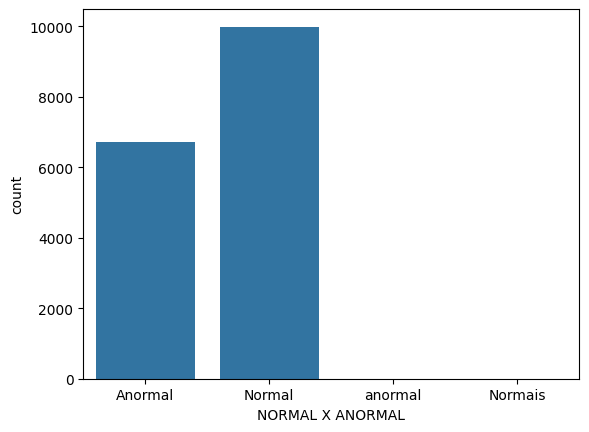

In [134]:
sns.countplot(x='NORMAL X ANORMAL', data=raw_data, )
plt.show()

### Relação entre features com pair plot 

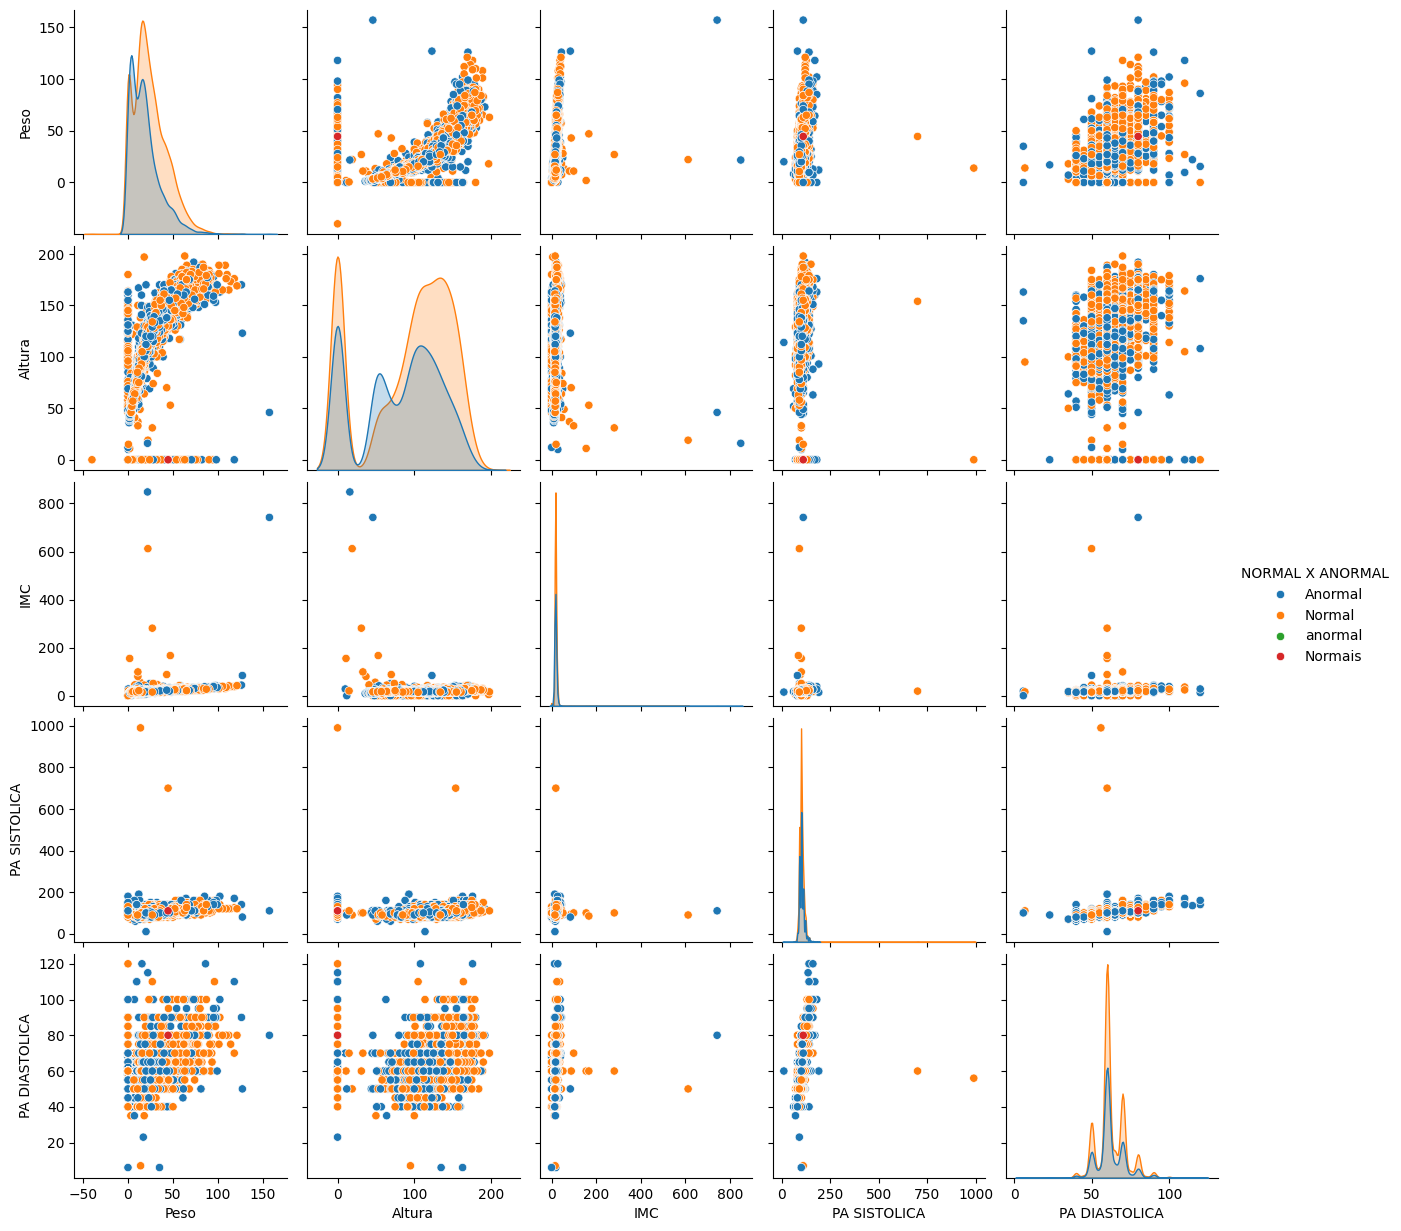

In [136]:
sns.pairplot(raw_data.drop(['ID'], axis = 1),
            hue='NORMAL X ANORMAL')

Da figura acima, podemos concluir o seguinte ponto principal sobre a **raw data**:
* É evidente a presença de **ruído** e/ou **erros de registo** nos dados, que **manifestam-se como outliers extremos**.
    * Alguns exemplos:
        * Altura a zero:  causa a que se forme uma linha/coluna que representam Altura=0 (o que não é um valor possivel)
        * Pesos negativos : por exemplo na relação entre Peso e Altura.
        * IMC Impossivel : valores de IMC que são impossiveis de atingir (e.g. relação IMC e PA Sistolica tem valor de IMC entre [600,800])
        * etc..
* Não é possivel estabelecer nenhuma relação linear ou padrões claros quando verificamos a relação entre features da **raw data**
    * A unica exceção é a relação entre altura e peso (embora demonstre algum ruido) 

### Histograms

Histograms allow seeing the distribution of data for various columns. It can be used for uni as well as bi-variate analysis.



--- Gerando Histogramas para Features Numéricas ---


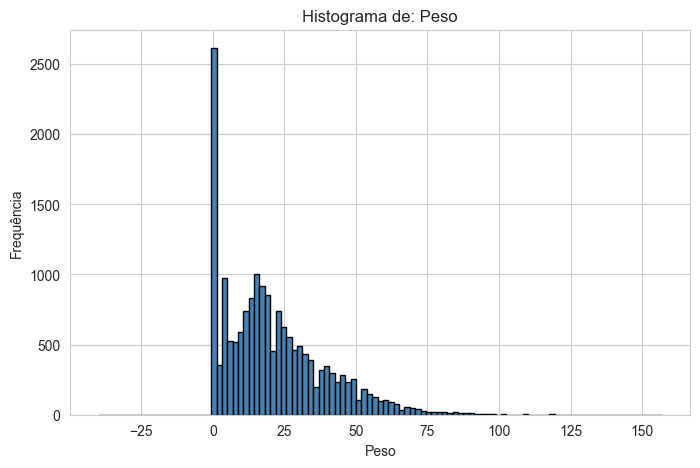

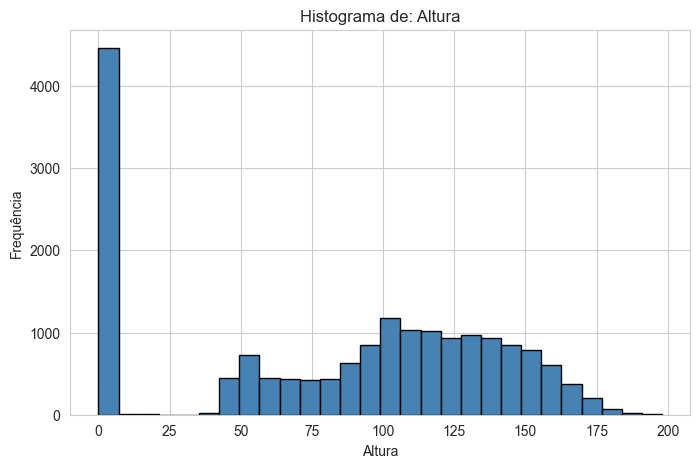

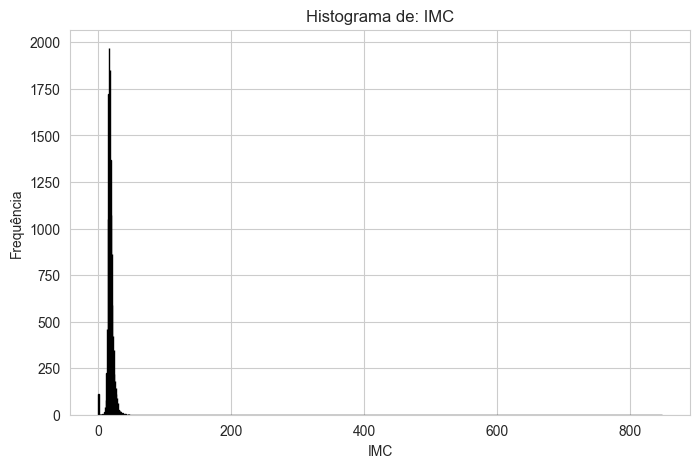

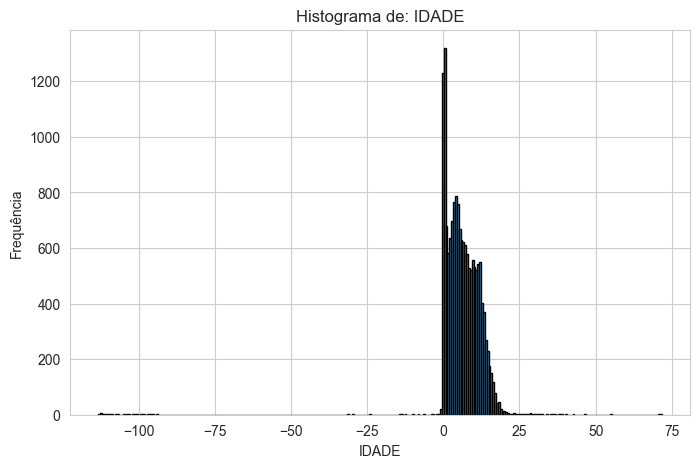

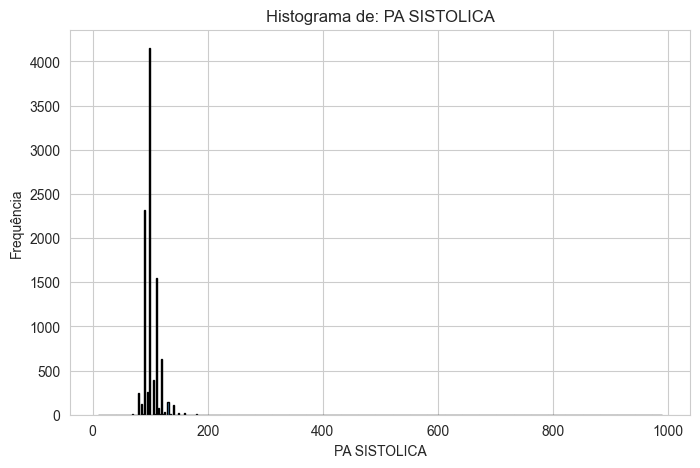

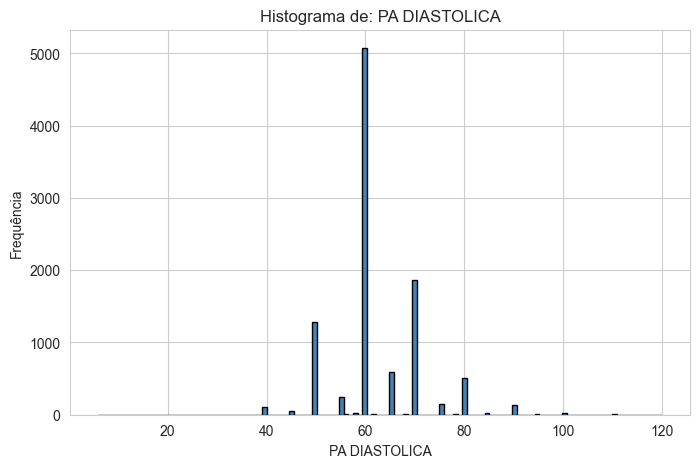

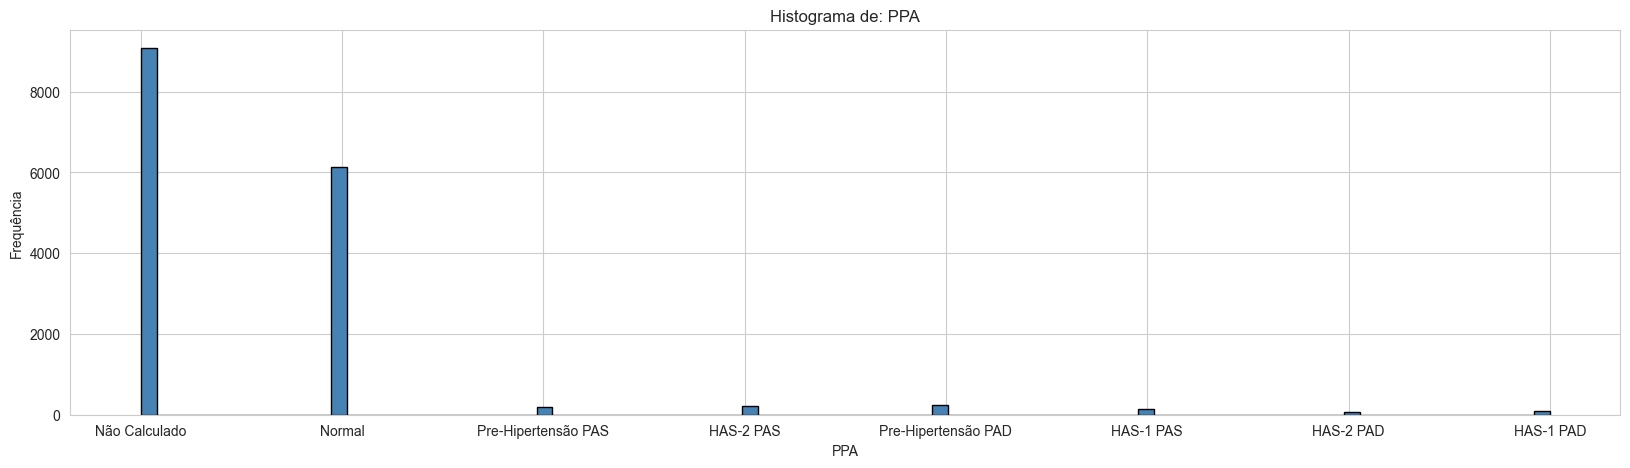

Não foi possível fazer o plot de FC (talvez 'fd' falhou): '<=' not supported between instances of 'int' and 'str'


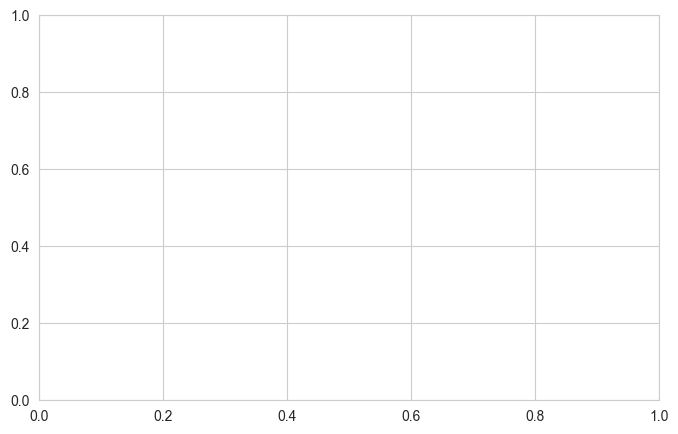


--- Gerando Gráficos de Barras para Features Categóricas ---


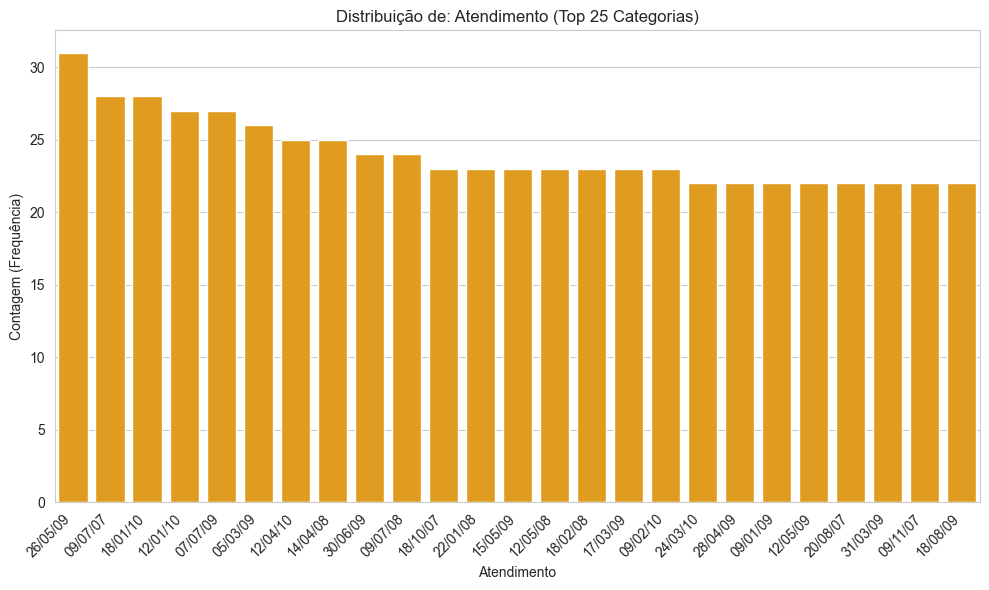

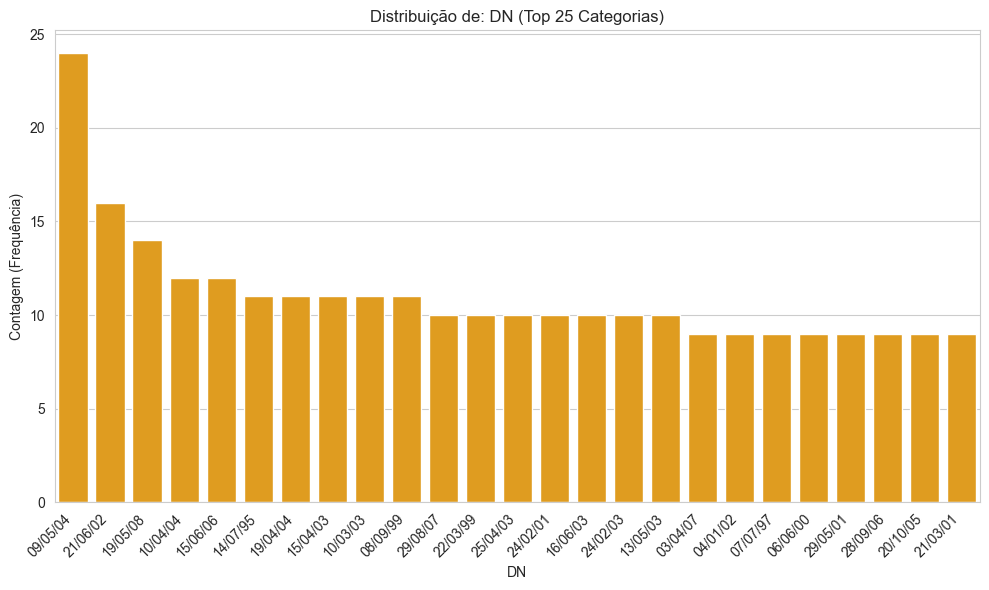

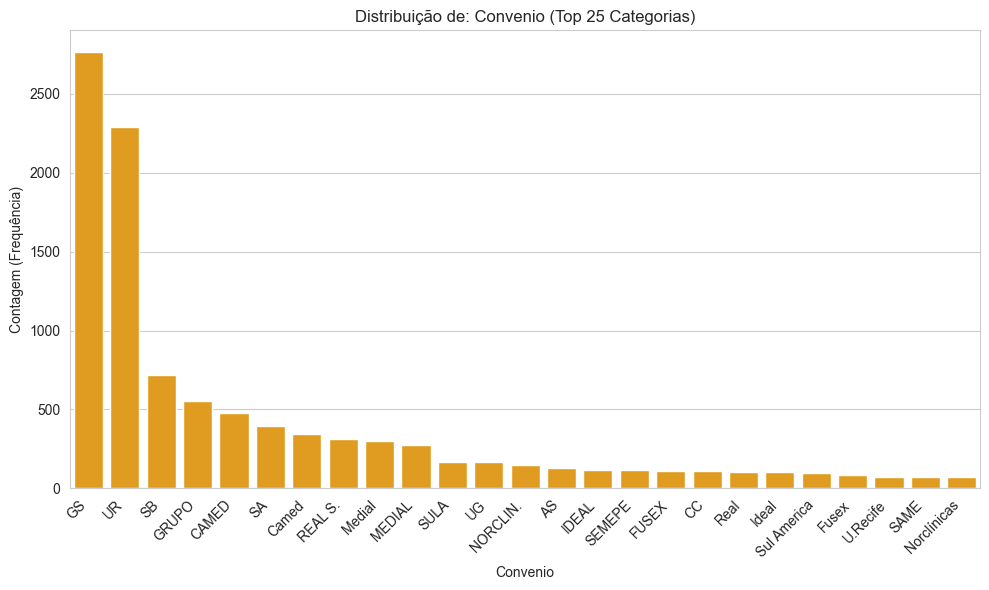

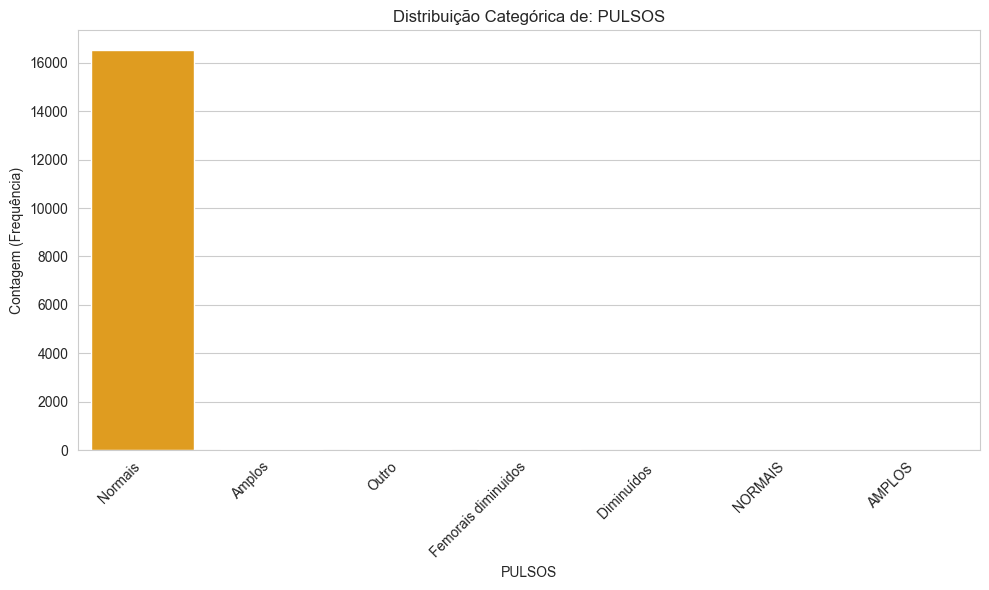

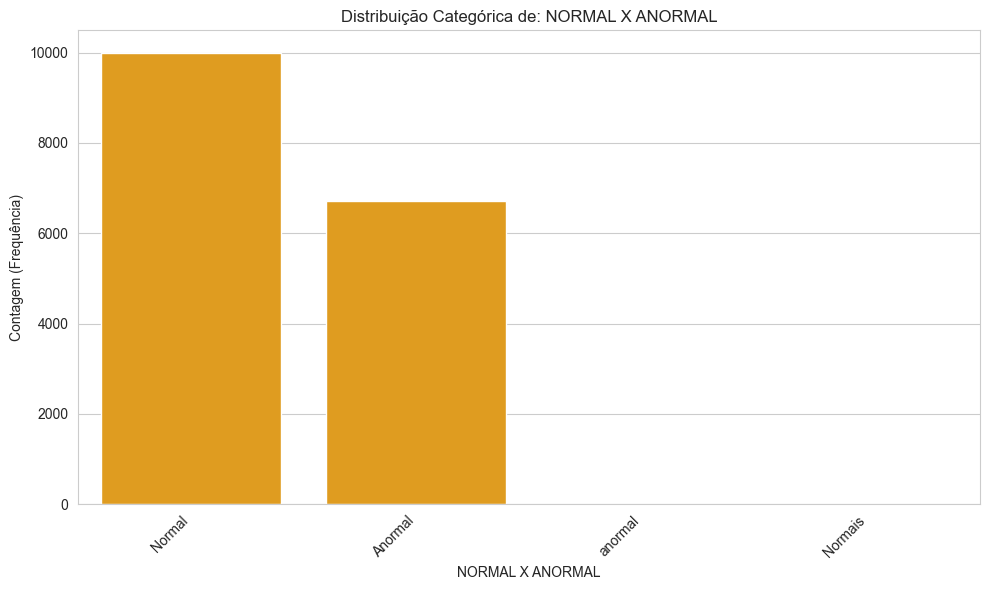

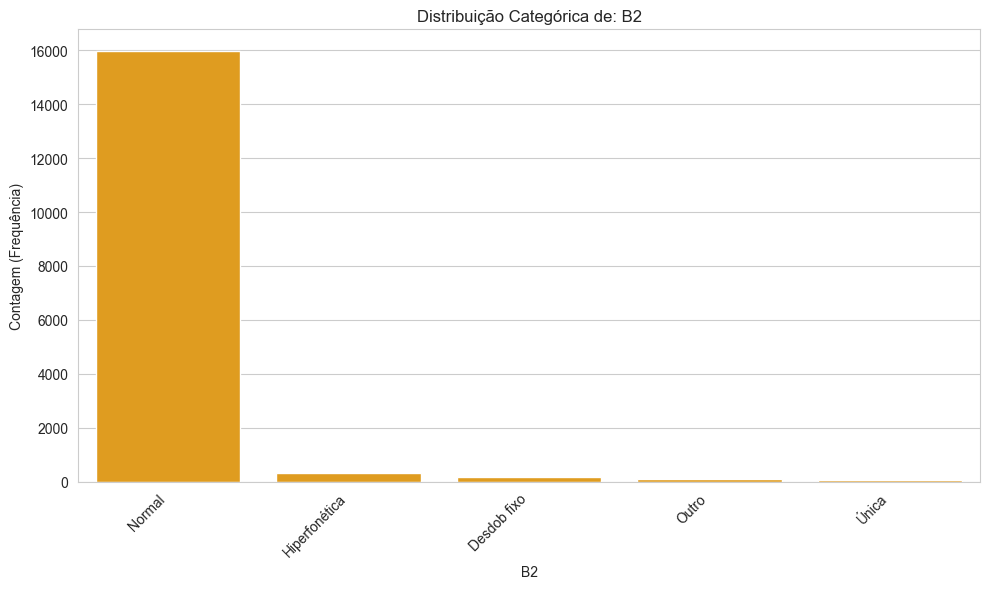

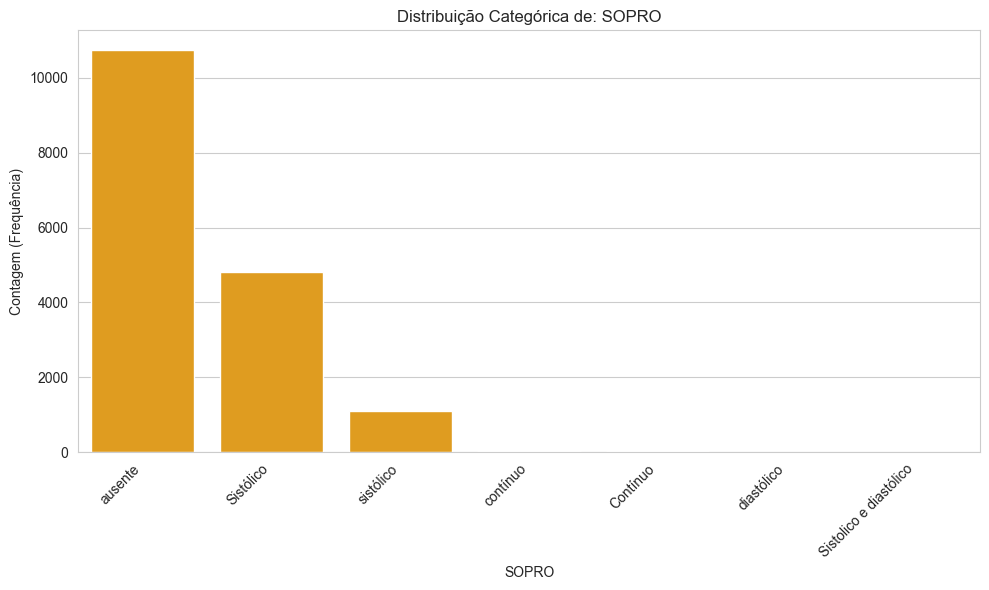

Não foi possível plotar HDA1 (pode ser um erro de tipo de dado): 'HDA1'


<Figure size 1000x600 with 0 Axes>

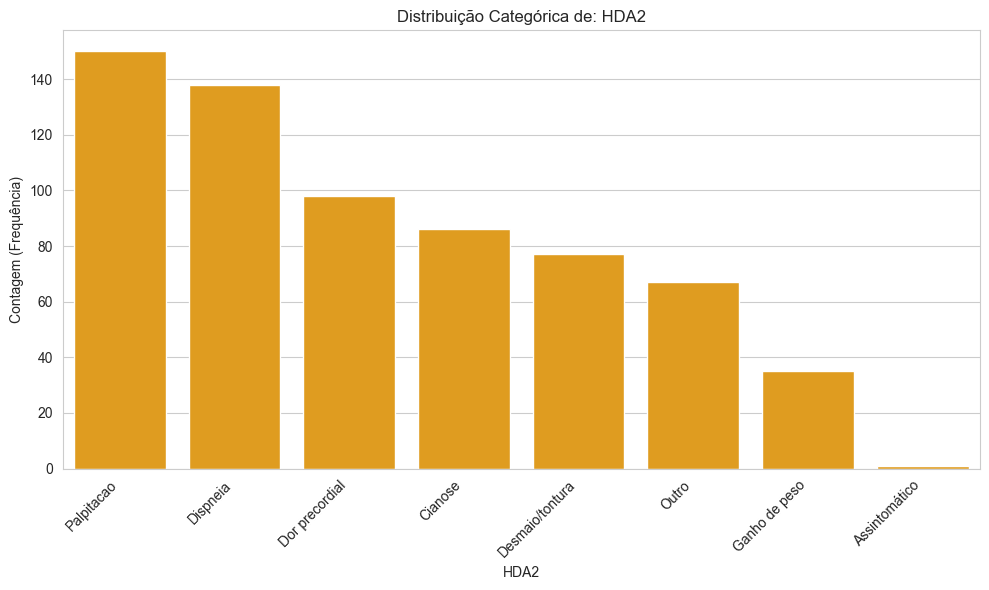

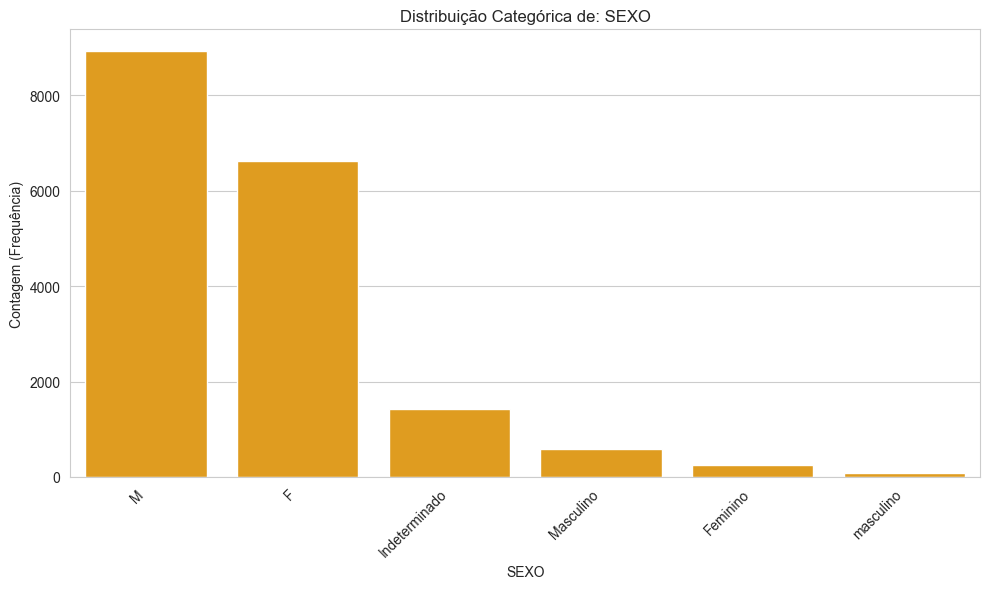

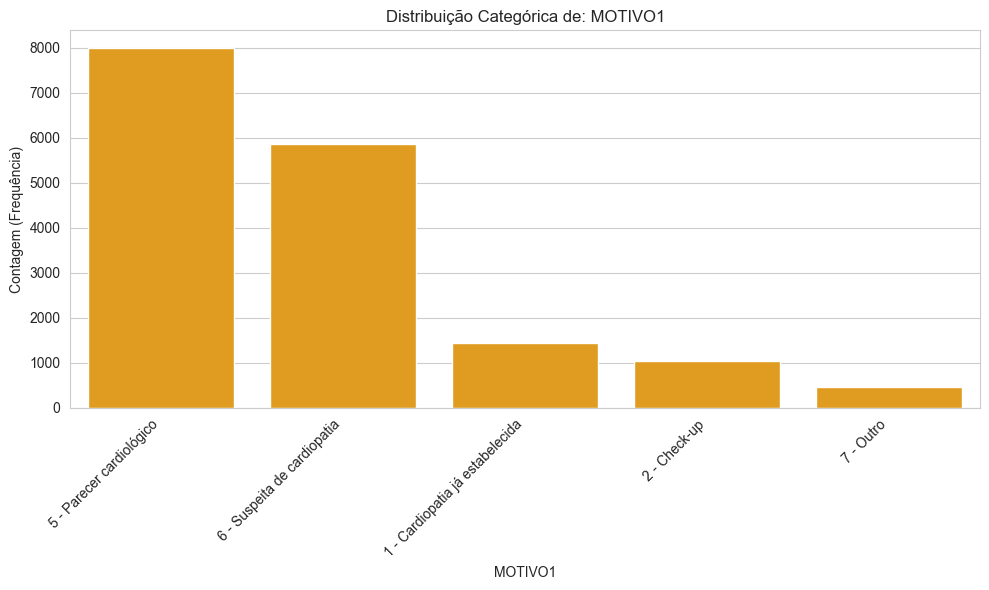

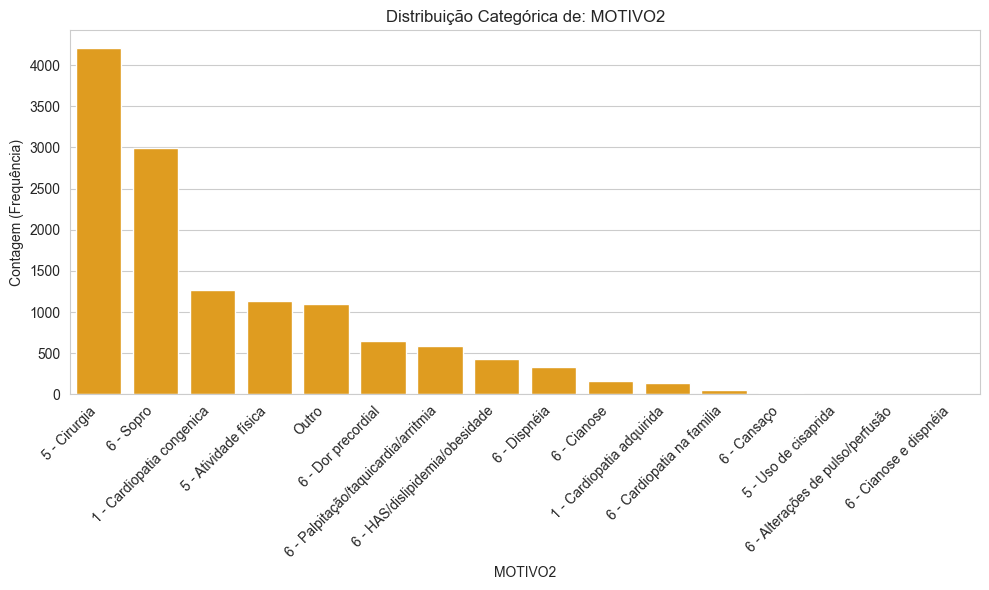

In [115]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Assumindo que o seu DataFrame se chama 'raw_data'
# (Certifique-se de que 'raw_data' está carregado)

# 1. Definir as listas de features com base na sua imagem
# (Excluindo 'ID')

# Features Numéricas (Ratio ou Interval) para Histogramas
numeric_features = [
    'Peso', 'Altura', 'IMC', 'IDADE', 
    'PA SISTOLICA', 'PA DIASTOLICA', 'PPA', 'FC'
]

# Features Categóricas (Nominal) para Gráficos de Barras
# Nota: 'Atendimento' e 'DN' são Intervalo (datas) na tabela,
# mas são melhor visualizados como categorias (countplots).
categorical_features = [
    'Atendimento', 'DN', 'Convenio', 'PULSOS', 
    'NORMAL X ANORMAL', 'B2', 'SOPRO', 
    'HDA1', 'HDA2', 'SEXO', 'MOTIVO1', 'MOTIVO2'
]

# Definir o estilo (opcional)
sns.set_style("whitegrid")

# --- 2. Plotar Histogramas para Features Numéricas ---
print("--- Gerando Histogramas para Features Numéricas ---")
for feature in numeric_features:
    # Criar uma nova figura para cada plot (sem subplots)
    if feature == 'PPA': 
        plt.figure(figsize=(20, 5))
    else:
        plt.figure(figsize=(8, 5))
    
    # Usar .dropna() para remover valores NaN (missing) antes de plotar
    # O 'bins='fd'' (Freedman-Diaconis) pode falhar se houver muitos NaNs
    try:
        data_to_plot = raw_data[feature].dropna()
        plt.hist(data_to_plot, bins='fd', color='steelblue', edgecolor='black')
        plt.title(f'Histograma de: {feature}')
        plt.xlabel(feature)
        plt.ylabel('Frequência')
    except Exception as e:
        # Captura erros se 'fd' falhar (ex: dados insuficientes após dropna)
        print(f"Não foi possível fazer o plot de {feature} (talvez 'fd' falhou): {e}")
        
    plt.show() # Exibe o gráfico imediatamente


# --- 3. Plotar Gráficos de Barras (Countplots) para Features Categóricas ---
print("\n--- Gerando Gráficos de Barras para Features Categóricas ---")
for feature in categorical_features:
    # Criar uma nova figura para cada plot
    plt.figure(figsize=(10, 6))
    
    # Usar sns.countplot para a visualização categórica "correta"
    
    # Calcular a ordem (do mais frequente para o menos frequente)
    try:
        # Obter o N de categorias únicas
        n_unique = raw_data[feature].nunique()
        
        plot_title = f'Distribuição Categórica de: {feature}'
        order = raw_data[feature].value_counts().index
        
        # Ajuste para alta cardinalidade (ex: 'Atendimento', 'DN')
        # Se houver mais de 25 categorias, plotamos apenas as 25 principais
        if n_unique > 25:
            plot_title = f'Distribuição de: {feature} (Top 25 Categorias)'
            # Pegar o índice das 25 principais
            top_25 = order[:25]
            # Filtrar dados para plotar apenas o top 25
            plot_data = raw_data[raw_data[feature].isin(top_25)]
            sns.countplot(x=feature, data=plot_data, color='orange', order=top_25)
        else:
            # Plotar todas as categorias se forem 25 ou menos
            sns.countplot(x=feature, data=raw_data, color='orange', order=order)
        
        plt.title(plot_title)
        plt.xlabel(feature)
        plt.ylabel('Contagem (Frequência)')
        
        # Rotacionar os labels do eixo X para melhor leitura
        plt.xticks(rotation=45, ha='right')
        
    except Exception as e:
        print(f"Não foi possível plotar {feature} (pode ser um erro de tipo de dado): {e}")

    plt.tight_layout() # Ajusta o layout para evitar que os labels sejam cortados
    plt.show() # Exibe o gráfico imediatamente

* Alguns pontos que podemos concluir dos plots acima:
    * Existem alguns valores invalidos nas colunas que impedem fazer o respetivo plot (e.g. FN tem celulas com '#!Value')
    * A distribuição de algumas colunas (features) demonstram mais uma vez o ruido presente (e.g. picos a 0 de frequência e altura)
    * A distribuição dos dados categoricos, em alguns casos, faz com que tenha muitos objeto com uma certo valor e poucos com outro (e.g.  a feature PULSOS tem bastantes objetos e as restnates tem significativamente menos)



### Boxplots

* Um boxplot serve para visualizar a distribuição de um conjunto de dados. Ele mostra rapidamente 5 estatísticas principais:
    * O valor mínimo
    * O primeiro quartil (Q1 - 25% dos dados)
    * A mediana (Q2 - 50% dos dados, o valor central)
    * O terceiro quartil (Q3 - 75% dos dados)
    * O valor máximo
* É especialmente útil para identificar outliers (valores atípicos) e para comparar a distribuição de vários grupos lado a lado.
* O boxplot é desenhado para uma variável numérica (ex: "salário", "altura", "temperatura").
* No entanto, o seu uso mais comum e poderoso é para comparar essa variável numérica dividida por uma variável categórica (ex: comparar "Peso" (numérica) com a target feature "NORMAL X ANORMAL" (categorica)).

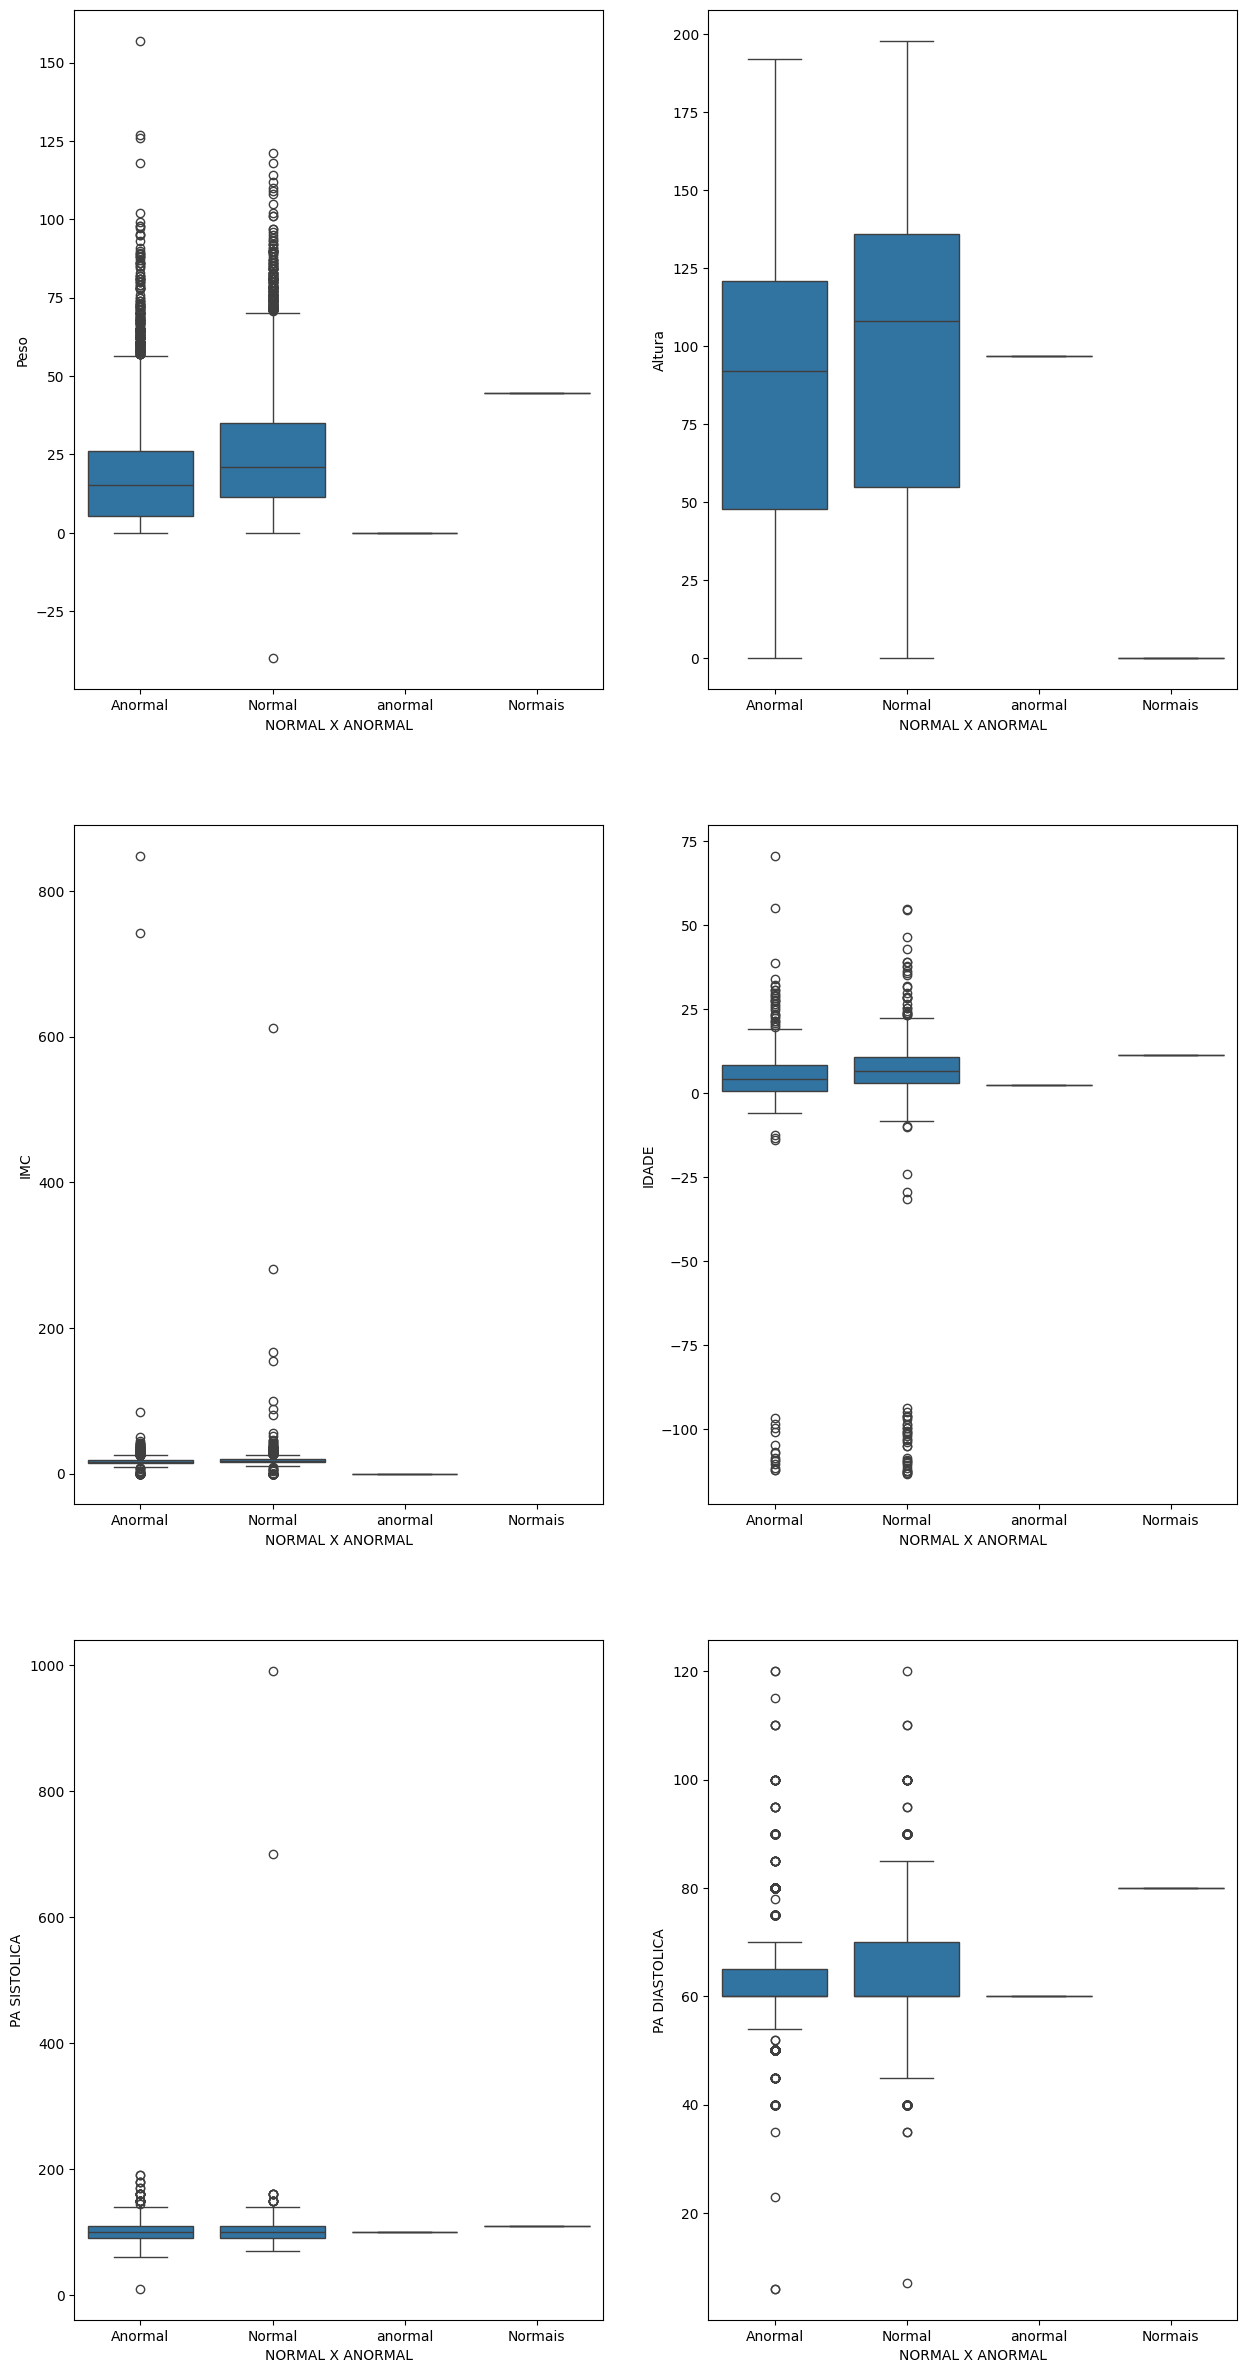

In [34]:
# importing packages
import seaborn as sns
import matplotlib.pyplot as plt

def graph(y):
    sns.boxplot(x="NORMAL X ANORMAL", y=y, data=raw_data)


plt.figure(figsize=(15,30))


# Boxplot de variaveis númerica contra target feature (NORMAL X ANORMAL)
plt.subplot(321)
graph('Peso')
plt.subplot(322)
graph('Altura')
plt.subplot(323)
graph('IMC')
plt.subplot(324)
graph('IDADE')
plt.subplot(325)
graph('PA SISTOLICA')
plt.subplot(326)
graph('PA DIASTOLICA')

#plt.subplot(428) 
#graph('FC')  (Não fiz plot do fc porque envolve )

* Com os gráficos acima podemos observar :
    * A distibuição das features númericos face a respetiva "classe" da target feature.
    * Os valores 'anormal' e 'Normais' são "erros de inserção", porque só existe um de cada (dai o boxplot achatado)
    * verificamos a presença dos outliers que em certos casos são valores impossiveis

### Spread measures 

* Enquanto a média  diz-nos onde está o "centro" dos  dados, as **medidas de dispersão** dizem-nos quão **"espalhados"** ou **"concentrados"** os dados estão à volta desse centro.
* As principais medidas de dispersão são:
    1. **Amplitude**
        * O que é?
            * É  a diferença entre o valor máximo e o valor mínimo no  conjunto de dados.
          * O obtemos com ela?
              * Noção imediata da "largura" total dos dados.
          * Desvantagem: **É extremamente sensível a outliers**.
              * Se tiver um único valor muito alto ou muito baixo, a amplitude será influenciada por ele e pode não representar bem a dispersão da maioria dos dados.
    2. **Amplitude Interquartil (IQR)**:
          * O que é?
          * Para a calcular, primeiro ordenamos os  dados e dividemos-os em quatro partes iguais (quartis):
              * Q1 (Primeiro Quartil): O valor abaixo do qual estão 25% dos dados.
              * Q2 (Segundo Quartil): A mediana (50% dos dados).
              * Q3 (Terceiro Quartil): O valor abaixo do qual estão 75% dos dados.
              * Fórmula: IQR = Q3 - Q1O que obtém com ela?
                  * O IQR representa a amplitude dos 50% "centrais" dos seus dados.
                  * Como "ignora" os 25% mais baixos e os 25% mais altos, **não é sensível a outliers**.
                  * É a medida de dispersão preferida quando os  dados são assimétricos (skewed) ou quando ha suspeita da existência de outliers.
                  * É a base para construir boxplots .
    3. **Variância**
          * O que é?
              * É uma medida mais complexa que calcula a média dos quadrados das diferenças entre cada valor e a média do conjunto de dados.
                  * Conceito: Mede "qual é, em média, o quadrado da distância de cada ponto até à média".
          * O que obtemos com  com ela?A variância (simbolizada como $\sigma^2$ para a população ou $s^2$ para uma amostra) é fundamental em muitas fórmulas estatísticas (como testes de hipóteses, ANOVA, etc.).
          * Desvantagem (para análise preliminar): A sua unidade de medida está "ao quadrado" (ex: se os seus dados são "euros", a variância é "euros ao quadrado"). Isto torna-a muito difícil de interpretar diretamente no contexto dos  dados originais.
          
    4. **Desvio Padrão (Standard Deviation)**
          * O que é?
              * Esta é provavelmente a medida de dispersão mais importante e mais utilizada.
              * É simplesmente a raiz quadrada da variância.
              * Fórmula: $\sigma = \sqrt{\sigma^2}$ (ou $s = \sqrt{s^2}$)
            * O que obtemos com ela?
                * Diz-nos, em média, o quão longe cada ponto de dados está da média do conjunto.
                * Um desvio padrão baixo significa que os dados estão muito concentrados ("agrupados") perto da média.
                * Um desvio padrão alto significa que os dados estão muito espalhados por uma vasta gama de valores.
    5. **Coeficiente de Variação**
          * O que é?
              *  É uma medida de dispersão relativa.
              *  É o rácio (relação) entre o desvio padrão e a média, geralmente expresso em percentagem.
              *  Fórmula: CV = (Desvio Padrão / Média) * 100%
        *  O que obtemos com ela?
            *  Permite comparar a variabilidade de dois conjuntos de dados diferentes, mesmo que tenham médias ou unidades de medida distintas.

> TODO calcular as spread measures 

### Density  

> TODO FAZER, E DESCOBRIR COMO FAZER (JÁ PERGUNTEI AO GEMINI E ELE SUGERIU FAZER UM TIPO DE GRÁFICO PARA ISSO)

### Correlation

> TODO fazer algo parecido ao que esta no FDS_4 